

```
Prática N°5 - Aprendizaje Profundo
```



# **APRENDIZAJE SEMI - SUPERVISADO**

##*DataSet: Chest xRay*


###00. Librerías

In [1]:
# !pip install -q fastai

In [2]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from fastai.vision.all import *
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from IPython.display import display, HTML
import seaborn as sns

###01. Dataset

In [3]:
BASE_PATH = Path("/content")
DATA_PATH = BASE_PATH / "data"
DATA_PATH.mkdir(exist_ok=True)

In [4]:
!wget -O /content/chest_xray.zip "https://www.dropbox.com/s/q6s4wu7q3yrpwrm/chest_xray.zip?dl=1"

--2026-04-10 08:46:20--  https://www.dropbox.com/s/q6s4wu7q3yrpwrm/chest_xray.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/wkqbmnizhlprn6gonajmi/chest_xray.zip?rlkey=y027u6emex8jsgirnx9bj2zho&dl=1 [following]
--2026-04-10 08:46:21--  https://www.dropbox.com/scl/fi/wkqbmnizhlprn6gonajmi/chest_xray.zip?rlkey=y027u6emex8jsgirnx9bj2zho&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc88fd23877b4d6292bc2bad8c27.dl.dropboxusercontent.com/cd/0/inline/C-XtwTEMex1SAJBngm7wUGllRK5jUxXgR3ZOszytTjVUiFXfOySsmIqkaCI8l3MlbRFFQZWAg8XXJS3F-CoAugvctMh8ffbKlczUk_ZEtGCuMNM430_kVh95Huk7MHPaiEY/file?dl=1# [following]
--2026-04-10 08:46:22--  https://uc88fd23877b4d6292bc2bad8c27.dl.dropboxusercontent.com/cd/0/i

In [5]:
!unzip -q /content/chest_xray.zip -d /content/data/

In [6]:
# Verificar estructura original del dataset
dataset_root = BASE_PATH
print("Contenido principal:", os.listdir(dataset_root))

for split in ["train", "test", "val"]:
    split_path = dataset_root / split
    if split_path.exists():
        print(f"\n{split.upper()}:")
        for cls in os.listdir(split_path):
            cls_path = split_path / cls
            if cls_path.is_dir():
                print(f"  {cls}: {len(list(cls_path.glob('*')))} imágenes")

Contenido principal: ['.config', 'chest_xray.zip', 'data', 'sample_data']


Vamos a simular un entorno semi-supervisado para lo cual tienes que reestructurar tu dataset de manera que en el conjunto de entrenamiento haya únicamente 20 imágenes por clase, y el resto de imágenes las guardarás en una carpeta llamada unlabelled. Al acabar, tu estructura de carpetas debería ser algo similar a lo siguiente:

```.
└── dataset
    ├── test
    │   ├── claseA
    │   └── claseB
    ├── train
    │   ├── claseA
    │   └── claseB
    └── unlabelled
```

In [7]:
# Construcción del dataset semi-supervisado
random.seed(42)

original_root = Path(f"{BASE_PATH}/data/chest_xray")
semi_root = Path(f"{BASE_PATH}/semi_supervised_dataset")

# Limpiar si existe
if semi_root.exists():
    shutil.rmtree(semi_root)

# Crear estructura
(semi_root / "train").mkdir(parents=True, exist_ok=True)
(semi_root / "test").mkdir(parents=True, exist_ok=True)
(semi_root / "unlabelled").mkdir(parents=True, exist_ok=True)

# Copiar test completo
for cls_dir in (original_root / "test").iterdir():
    if cls_dir.is_dir():
        dest_cls = semi_root / "test" / cls_dir.name
        dest_cls.mkdir(parents=True, exist_ok=True)
        for img_path in cls_dir.glob("*"):
            shutil.copy(img_path, dest_cls / img_path.name)

# Crear train reducido (20 por clase) + unlabelled
for cls_dir in (original_root / "train").iterdir():
    if cls_dir.is_dir():
        class_name = cls_dir.name
        train_dest = semi_root / "train" / class_name
        train_dest.mkdir(parents=True, exist_ok=True)

        images = list(cls_dir.glob("*"))
        random.shuffle(images)

        for img_path in images[:20]:
            shutil.copy(img_path, train_dest / img_path.name)
        for img_path in images[20:]:
            shutil.copy(img_path, semi_root / "unlabelled" / f"{class_name}_{img_path.name}")

print("Dataset semi-supervisado creado en:", semi_root)

Dataset semi-supervisado creado en: /content/semi_supervised_dataset


In [8]:
# Resumen del dataset
print("="*40)
print("DISTRIBUCIÓN DEL DATASET")
print("="*40)

print("\nTRAIN (etiquetado):")
for cls_dir in sorted((semi_root / "train").iterdir()):
    if cls_dir.is_dir():
        print(f"  {cls_dir.name}: {len(list(cls_dir.glob('*')))} imágenes")

print("\nTEST:")
for cls_dir in sorted((semi_root / "test").iterdir()):
    if cls_dir.is_dir():
        print(f"  {cls_dir.name}: {len(list(cls_dir.glob('*')))} imágenes")

n_unlabelled = len(list((semi_root / "unlabelled").glob("*")))
print(f"\nUNLABELLED: {n_unlabelled} imágenes")
print("="*40)

DISTRIBUCIÓN DEL DATASET

TRAIN (etiquetado):
  NORMAL: 20 imágenes
  PNEUMONIA: 20 imágenes

TEST:
  NORMAL: 234 imágenes
  PNEUMONIA: 390 imágenes

UNLABELLED: 5194 imágenes


### 02. DataLoaders & Entrenamiento Modelo Base

Clases: ['NORMAL', 'PNEUMONIA']


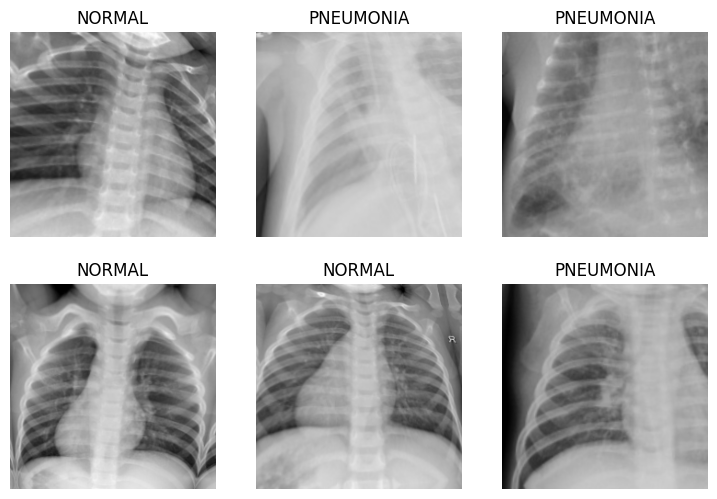

In [9]:
path = semi_root

dls = ImageDataLoaders.from_folder(
    path / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

dls.show_batch(max_n=6)
print("Clases:", dls.vocab)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


<div></div>


LR sugerido (valley): 2.09e-03
LR sugerido (steep):  1.45e-03


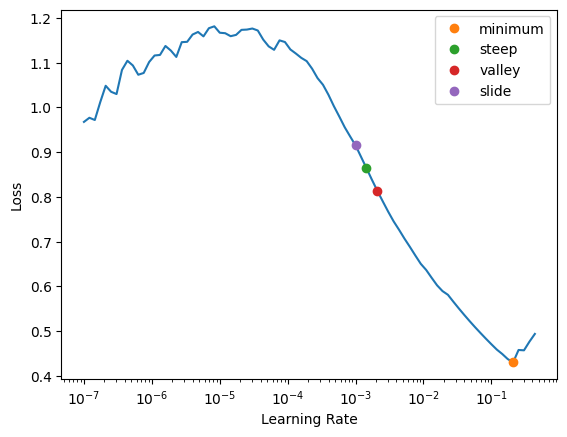

In [10]:
# Búsqueda del mejor Learning Rate
learn = vision_learner(dls, resnet18, metrics=accuracy)

# lr_find ejecuta un mini-entrenamiento barriendo LRs
# y devuelve la curva loss vs LR
lr_result = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
print(f"\nLR sugerido (valley): {lr_result.valley:.2e}")
print(f"LR sugerido (steep):  {lr_result.steep:.2e}")

In [11]:
# Selección del LR óptimo a partir del resultado del lr_find
# Usamos el valor 'valley' que indica el punto más estable de descenso
best_lr = lr_result.valley
print(f"Learning rate seleccionado: {best_lr:.2e}")

Learning rate seleccionado: 2.09e-03


###03. Entrenamiento del Modelo Base con LR

In [12]:
# Entrenamiento del modelo base con el LR óptimo
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(5, base_lr=best_lr)

epoch,train_loss,valid_loss,accuracy,time
0,1.211746,1.179932,0.625000,00:00


epoch,train_loss,valid_loss,accuracy,time
0,1.282316,0.857114,0.500000,00:00
1,1.411535,1.217283,0.750000,00:00
2,1.035510,1.835256,0.750000,00:00
3,0.868089,2.143434,0.750000,00:00
4,0.731478,2.048911,0.750000,00:00


In [13]:
# Evaluación en el conjunto de TEST
test_files = get_image_files(path / "test")
test_dl = learn.dls.test_dl(test_files)

preds, _ = learn.get_preds(dl=test_dl)
pred_labels = preds.argmax(dim=1)
true_labels = [learn.dls.vocab.o2i[f.parent.name] for f in test_files]

acc_base = accuracy_score(true_labels, pred_labels.cpu().numpy())
print(f"\n{'='*40}")
print(f"Accuracy en TEST (modelo base): {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"{'='*40}")


Accuracy en TEST (modelo base): 0.4038 (40.38%)


In [14]:
# Informe detallado por clase
print("\nCLASSIFICATION REPORT (modelo base):")
print(classification_report(
    true_labels,
    pred_labels.cpu().numpy(),
    target_names=learn.dls.vocab
))


CLASSIFICATION REPORT (modelo base):
              precision    recall  f1-score   support

      NORMAL       0.39      1.00      0.56       234
   PNEUMONIA       1.00      0.05      0.09       390

    accuracy                           0.40       624
   macro avg       0.69      0.52      0.32       624
weighted avg       0.77      0.40      0.26       624



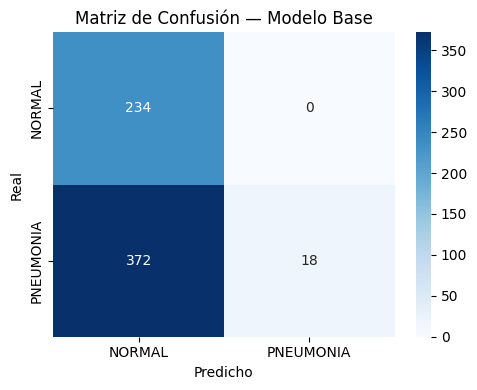

In [15]:
# Matriz de confusión — modelo base
cm = confusion_matrix(true_labels, pred_labels.cpu().numpy())
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=learn.dls.vocab,
            yticklabels=learn.dls.vocab, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Modelo Base')
plt.tight_layout()
plt.show()

###04. Pseudo - Labeling

Total imágenes sin etiquetar: 5192


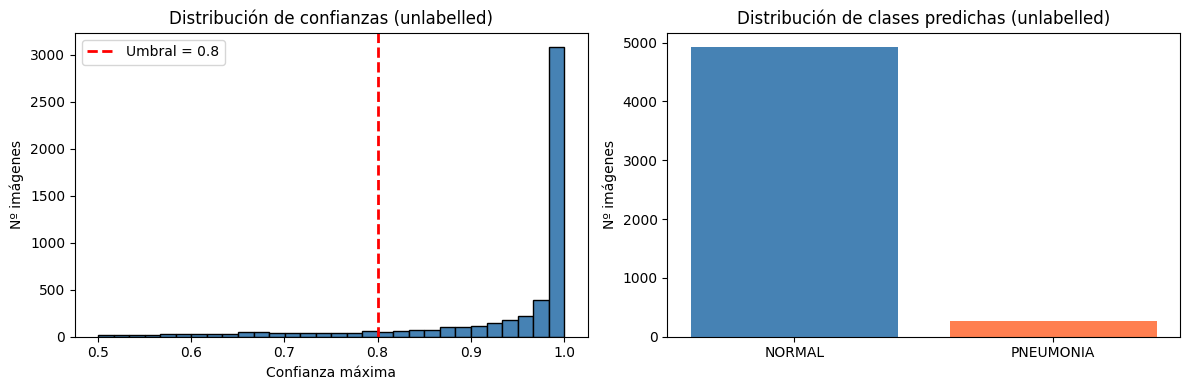


Imágenes con confianza >= 0.8: 4574 (88.1%)
Imágenes que quedarían sin etiquetar: 618

Clases predichas (todas las imágenes unlabelled):
  NORMAL: 4920 imágenes (94.8%)
  PNEUMONIA: 272 imágenes (5.2%)


In [16]:
# Análisis de confianzas ANTES de pseudo-etiquetar
unlabelled_files = get_image_files(semi_root / "unlabelled")
print(f"Total imágenes sin etiquetar: {len(unlabelled_files)}")

ul_dl = learn.dls.test_dl(unlabelled_files)
preds_ul, _ = learn.get_preds(dl=ul_dl)

max_probs = preds_ul.max(dim=1).values.cpu().numpy()
pred_classes = preds_ul.argmax(dim=1).cpu().numpy()

# Histograma de confianzas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_probs, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Umbral = 0.8')
axes[0].set_xlabel('Confianza máxima')
axes[0].set_ylabel('Nº imágenes')
axes[0].set_title('Distribución de confianzas (unlabelled)')
axes[0].legend()

# Distribución de clases predichas
class_counts = Counter(pred_classes)
axes[1].bar(
    [learn.dls.vocab[k] for k in sorted(class_counts)],
    [class_counts[k] for k in sorted(class_counts)],
    color=['steelblue', 'coral']
)
axes[1].set_title('Distribución de clases predichas (unlabelled)')
axes[1].set_ylabel('Nº imágenes')

plt.tight_layout()
plt.show()

n_above_threshold = (max_probs >= 0.8).sum()
print(f"\nImágenes con confianza >= 0.8: {n_above_threshold} ({n_above_threshold/len(max_probs)*100:.1f}%)")
print(f"Imágenes que quedarían sin etiquetar: {len(max_probs) - n_above_threshold}")
print("\nClases predichas (todas las imágenes unlabelled):")
for cls_idx, count in sorted(class_counts.items()):
    print(f"  {learn.dls.vocab[cls_idx]}: {count} imágenes ({count/len(pred_classes)*100:.1f}%)")

In [17]:
# FIX 1 — Función de pseudo-labeling con límite por clase para evitar desequilibrio
def pseudo_label_images(learn, unlabelled_dir, train_dir, threshold=0.8, max_per_class=None):
    """
    Etiqueta imágenes sin etiquetar y las mueve a train si superan el umbral de confianza.

    Parámetros:
    - threshold: confianza mínima para aceptar una pseudo-etiqueta (default 0.8)
    - max_per_class: máximo de imágenes a añadir por clase. Si es None, sin límite.
                     Usar para evitar desequilibrios cuando el modelo tiene sesgo de clase.
    """
    unlabelled_images = get_image_files(unlabelled_dir)
    print(f"Total de imágenes sin etiquetar: {len(unlabelled_images)}")
    moved_count = 0
    class_moved = Counter()

    if len(unlabelled_images) == 0:
        return 0, Counter()

    test_dl = learn.dls.test_dl(unlabelled_images)
    preds, _ = learn.get_preds(dl=test_dl)
    probs, classes = torch.max(preds, dim=1)

    for img_path, prob, cls in zip(unlabelled_images, probs, classes):
        if float(prob) >= threshold:
            class_name = learn.dls.vocab[cls]
            # FIX: respetar el límite por clase si está definido
            if max_per_class is not None and class_moved[class_name] >= max_per_class:
                continue
            dest_dir = Path(train_dir) / class_name
            dest_dir.mkdir(parents=True, exist_ok=True)
            shutil.move(str(img_path), dest_dir / img_path.name)
            moved_count += 1
            class_moved[class_name] += 1

    return moved_count, class_moved

In [18]:
# FIX 2 — Eliminar carpetas espurias de train antes de pseudo-etiquetar
# (evita que FastAI detecte carpetas como 'models' como clases adicionales)
clases_validas = list(learn.dls.vocab)
for item in list((semi_root / "train").iterdir()):
    if item.is_dir() and item.name not in clases_validas:
        shutil.rmtree(item)
        print(f"Carpeta espuria eliminada de train/: '{item.name}'")
print(f"Clases válidas en train: {clases_validas}")

# Aplicación del pseudo-labeling con límite por clase
# Calculamos cuántas imágenes tiene la clase minoritaria original
# para no exceder ese ratio en el nuevo dataset
n_minority = 20  # imágenes originales por clase
max_pseudo_per_class = 500  # añadimos hasta 500 por clase como máximo equilibrado

moved, class_moved = pseudo_label_images(
    learn=learn,
    unlabelled_dir=semi_root / "unlabelled",
    train_dir=semi_root / "train",
    threshold=0.8,
    max_per_class=max_pseudo_per_class
)

remaining = len(list((semi_root / "unlabelled").glob("*")))
print(f"\nImágenes movidas a train: {moved}")
print(f"Quedan en unlabelled: {remaining}")
print("\nDistribución de clases pseudo-etiquetadas:")
for cls, count in sorted(class_moved.items()):
    print(f"  {cls}: {count}")

print("\nNueva distribución en TRAIN (solo carpetas de clases):")
for cls_dir in sorted((semi_root / "train").iterdir()):
    if cls_dir.is_dir() and cls_dir.name in clases_validas:
        print(f"  {cls_dir.name}: {len(list(cls_dir.glob('*')))} imágenes")

Carpeta espuria eliminada de train/: 'models'
Clases válidas en train: ['NORMAL', 'PNEUMONIA']
Total de imágenes sin etiquetar: 5192



Imágenes movidas a train: 591
Quedan en unlabelled: 4603

Distribución de clases pseudo-etiquetadas:
  NORMAL: 500
  PNEUMONIA: 91

Nueva distribución en TRAIN (solo carpetas de clases):
  NORMAL: 520 imágenes
  PNEUMONIA: 111 imágenes


Clases detectadas en el nuevo DataLoader: ['NORMAL', 'PNEUMONIA']


<div></div>

LR óptimo para modelo post pseudo-labeling: 1.00e-03


epoch,train_loss,valid_loss,accuracy,time
0,1.061299,0.623818,0.753968,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.825077,1.348769,0.452381,00:02
1,0.750156,1.251160,0.507937,00:03
2,0.727023,0.627870,0.777778,00:02
3,0.661604,0.324082,0.880952,00:02
4,0.605416,0.321783,0.873016,00:02


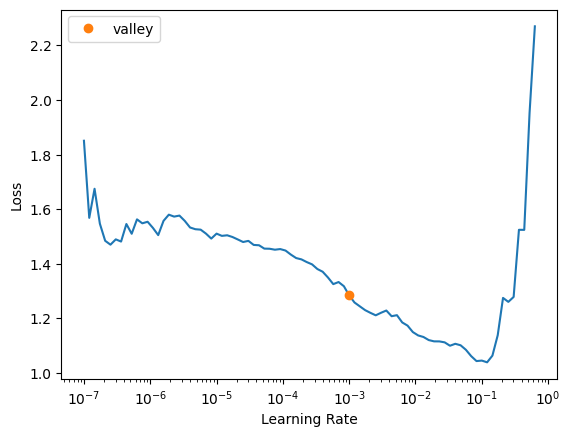

In [19]:
# FIX 2 (continuación) — Crear DataLoaders excluyendo carpetas no válidas
# Usamos una lista explícita de clases para evitar que carpetas espurias contaminen
dls_pseudo = ImageDataLoaders.from_folder(
    semi_root / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

print("Clases detectadas en el nuevo DataLoader:", dls_pseudo.vocab)

# Buscamos de nuevo el mejor LR para este nuevo dataset
learn_pseudo = vision_learner(dls_pseudo, resnet18, metrics=accuracy)
lr_result_pseudo = learn_pseudo.lr_find(suggest_funcs=(valley,))
best_lr_pseudo = lr_result_pseudo.valley
print(f"LR óptimo para modelo post pseudo-labeling: {best_lr_pseudo:.2e}")

learn_pseudo = vision_learner(dls_pseudo, resnet18, metrics=accuracy)
learn_pseudo.fine_tune(5, base_lr=best_lr_pseudo)

In [20]:
# Evaluación en test del modelo post pseudo-labeling
test_files = get_image_files(semi_root / "test")
test_dl_pseudo = learn_pseudo.dls.test_dl(test_files)

preds_pseudo, _ = learn_pseudo.get_preds(dl=test_dl_pseudo)
pred_labels_pseudo = preds_pseudo.argmax(dim=1)
true_labels_test = [learn_pseudo.dls.vocab.o2i[f.parent.name] for f in test_files]

acc_pseudo = accuracy_score(true_labels_test, pred_labels_pseudo.cpu().numpy())

mejora = acc_pseudo - acc_base
simbolo = "✅" if mejora > 0 else "❌"

print(f"\n{'='*50}")
print(f"Accuracy modelo BASE:             {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"Accuracy tras PSEUDO-LABELING:    {acc_pseudo:.4f} ({acc_pseudo*100:.2f}%)")
print(f"Diferencia:                       {simbolo} {mejora*100:+.2f} puntos porcentuales")
print(f"{'='*50}")


Accuracy modelo BASE:             0.4038 (40.38%)
Accuracy tras PSEUDO-LABELING:    0.4519 (45.19%)
Diferencia:                       ✅ +4.81 puntos porcentuales


In [21]:
# Classification report del modelo post pseudo-labeling
print("\nCLASSIFICATION REPORT (tras pseudo-labeling):")
print(classification_report(
    true_labels_test,
    pred_labels_pseudo.cpu().numpy(),
    target_names=learn_pseudo.dls.vocab
))


CLASSIFICATION REPORT (tras pseudo-labeling):
              precision    recall  f1-score   support

      NORMAL       0.40      0.98      0.57       234
   PNEUMONIA       0.91      0.14      0.24       390

    accuracy                           0.45       624
   macro avg       0.66      0.56      0.40       624
weighted avg       0.72      0.45      0.36       624



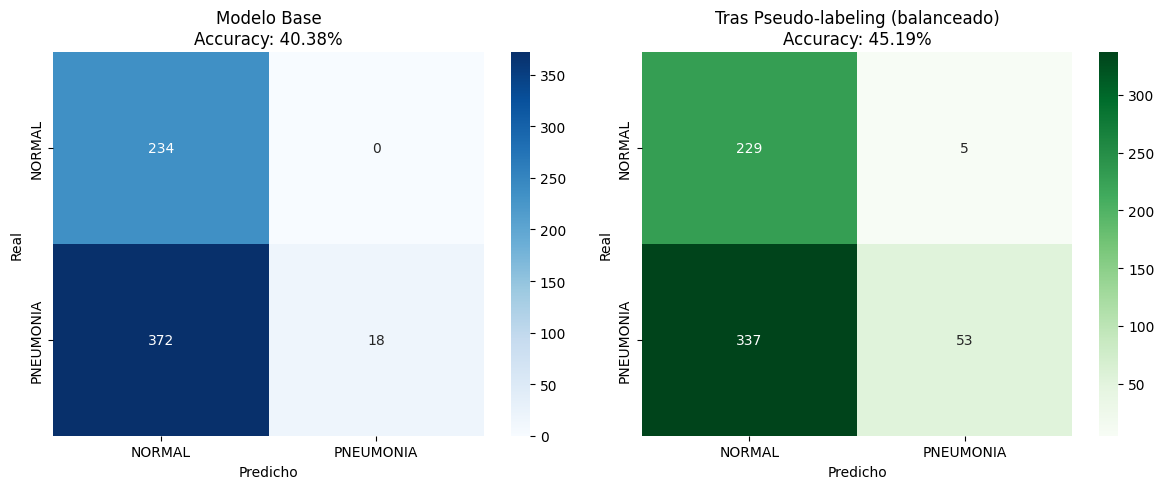

In [22]:
# Comparativa visual: matrices de confusión antes y después
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Recalcular predicciones del modelo base
test_dl_base = learn.dls.test_dl(test_files)
preds_base_final, _ = learn.get_preds(dl=test_dl_base)
pred_labels_base_final = preds_base_final.argmax(dim=1)
true_labels_base = [learn.dls.vocab.o2i[f.parent.name] for f in test_files]

cm_base = confusion_matrix(true_labels_base, pred_labels_base_final.cpu().numpy())
cm_pseudo = confusion_matrix(true_labels_test, pred_labels_pseudo.cpu().numpy())

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=learn.dls.vocab, yticklabels=learn.dls.vocab, ax=axes[0])
axes[0].set_title(f'Modelo Base\nAccuracy: {acc_base*100:.2f}%')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

sns.heatmap(cm_pseudo, annot=True, fmt='d', cmap='Greens',
            xticklabels=learn_pseudo.dls.vocab, yticklabels=learn_pseudo.dls.vocab, ax=axes[1])
axes[1].set_title(f'Tras Pseudo-labeling (balanceado)\nAccuracy: {acc_pseudo*100:.2f}%')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

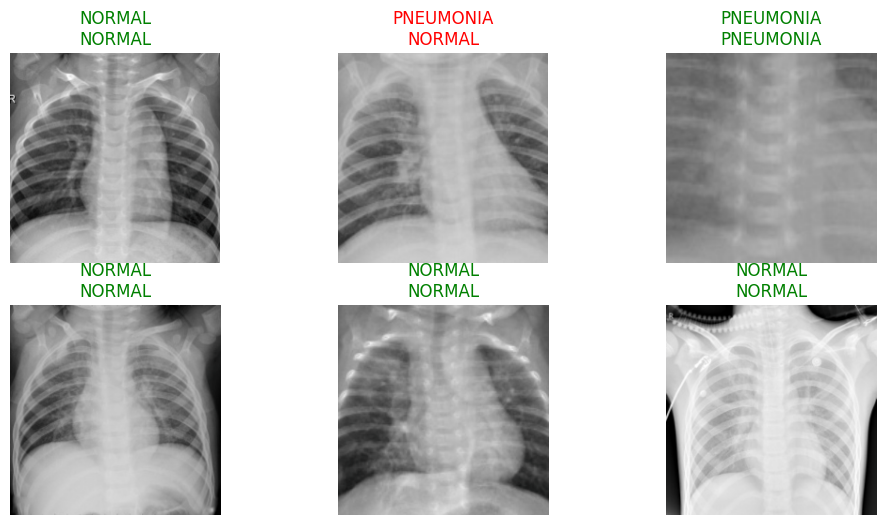

In [23]:
# Visualización de algunas imágenes con sus etiquetas predichas
learn_pseudo.show_results(max_n=6, figsize=(12, 6))

In [24]:
# FIX 3 — Tabla resumen con display(HTML(...)) para garantizar renderizado en Colab
from IPython.display import display, HTML

results = pd.DataFrame({
    "Modelo": [
        "Modelo base (40 imágenes etiquetadas)",
        "Modelo tras pseudo-labeling (balanceado)"
    ],
    "Imágenes en train": [
        40,
        40 + moved
    ],
    "Learning Rate": [
        f"{best_lr:.2e}",
        f"{best_lr_pseudo:.2e}"
    ],
    "Accuracy en TEST": [
        f"{acc_base*100:.2f}%",
        f"{acc_pseudo*100:.2f}%"
    ],
    "Mejora vs base": [
        "—",
        f"{(acc_pseudo - acc_base)*100:+.2f} pp"
    ]
})

# Renderizado HTML explícito — funciona siempre en Colab
html = results.to_html(index=False, border=1)
styled_html = f"""
<style>
  table {{ border-collapse: collapse; width: 100%; font-size: 14px; }}
  th {{ background-color: #4C72B0; color: white; padding: 10px; text-align: center; }}
  td {{ padding: 8px; text-align: center; border: 1px solid #ddd; }}
  tr:nth-child(even) {{ background-color: #f2f2f2; }}
</style>
{html}
"""
display(HTML(styled_html))

Modelo,Imágenes en train,Learning Rate,Accuracy en TEST,Mejora vs base
Modelo base (40 imágenes etiquetadas),40,2.09e-03,40.38%,—
Modelo tras pseudo-labeling (balanceado),631,1.00e-03,45.19%,+4.81 pp
